In [11]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from matplotlib.gridspec import GridSpec

In [2]:
def load_pickle(file):
    """
    load a pickle file into a local variable
    can be a pandas dataframe or dictionary
    """
    pickle_in = open(file, "rb")
    pickle_file = pickle.load(pickle_in)
    pickle_in.close()
    return pickle_file

In [17]:
noises = [0, 5, 10, 15, 20]
len_period = 20
node_dict = load_pickle('../node_dictionary.pickle')
input_nodes = node_dict['GENETIC'] + node_dict['MOLECULAR'] + node_dict['PET'] + node_dict['MRI'] + node_dict['RISKFACTORS']

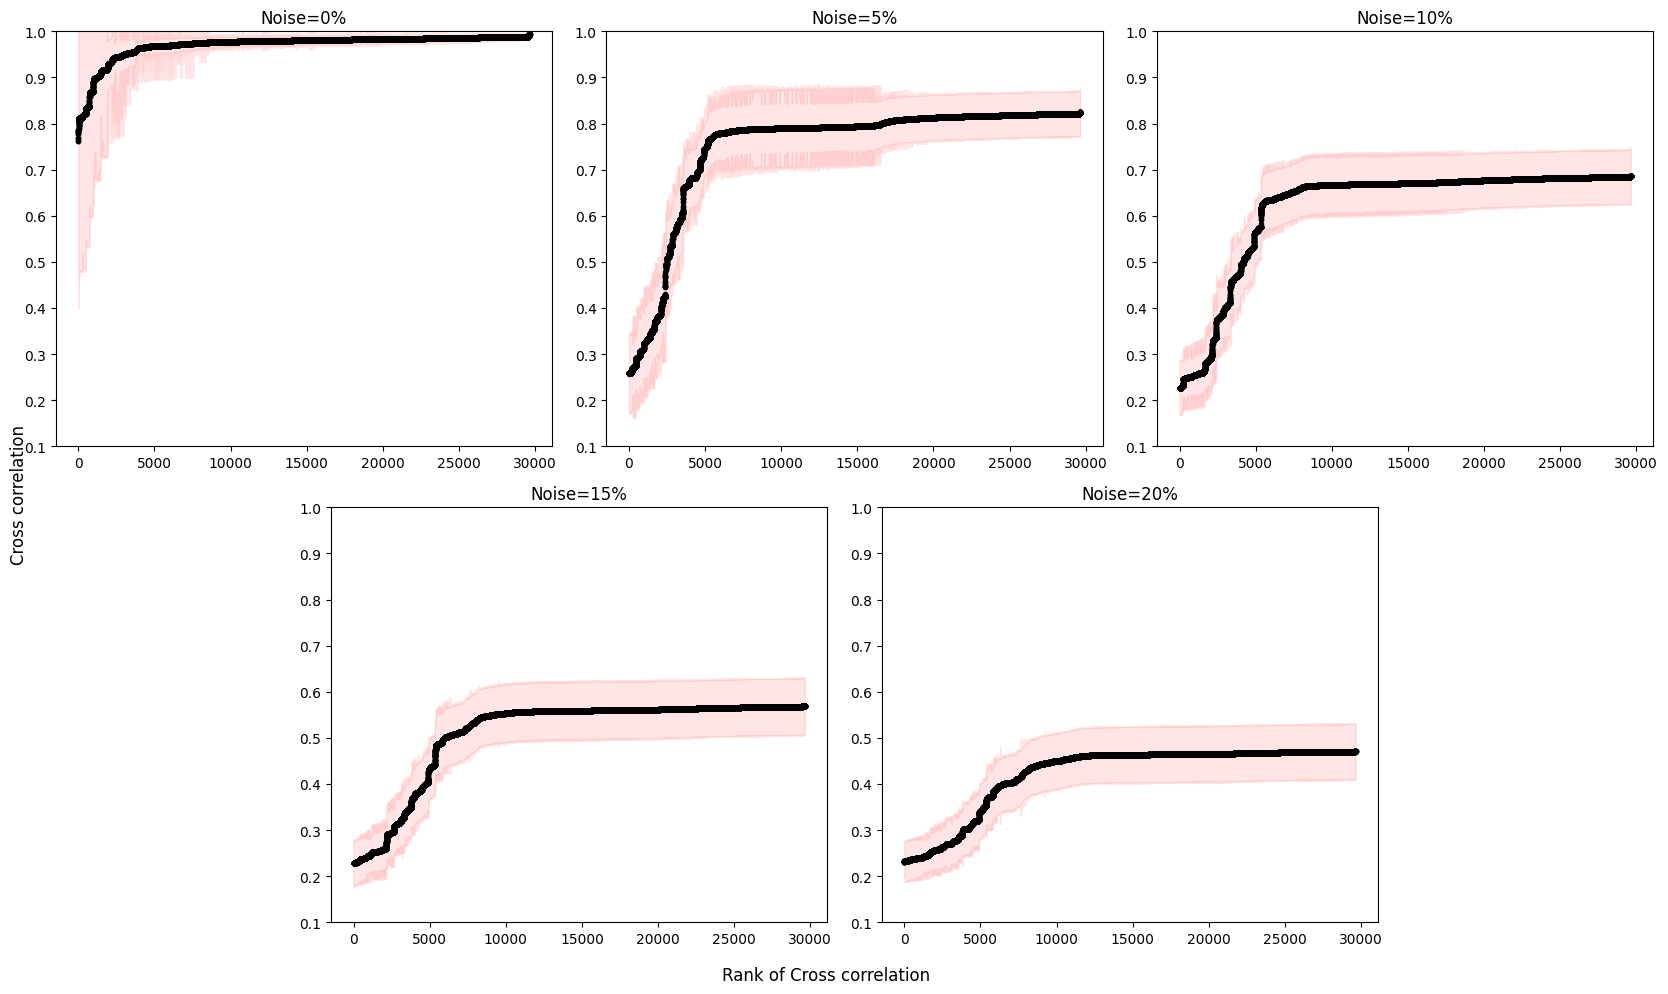

In [ ]:
# fig, axes = plt.subplots(1, len(noises), figsize=(17,3))
# for k, noise in enumerate(noises):
#     cross_corr = {'mean': [], 'std': []}
#     for in_node in input_nodes:
#         file = f'/paper/results_pearson/network_paths/{in_node}/period_{len_period}/cross_corr_noise_{noise}.pickle'
#         in_cross = load_pickle(file)
#         cross_corr['mean'].append(in_cross['mean'].to_numpy())
#         cross_corr['std'].append(in_cross['std'].to_numpy())
#     total_mean = np.mean(np.array([i for i in cross_corr['mean']]), axis=0)
#     total_std = np.mean(np.array([i for i in cross_corr['std']]), axis=0)
#     n = total_mean.shape[0]
#     list_mean = []
#     list_std = []
#     for i in range(n):
#         for j in range(n):
#             if i < j:
#                 list_mean.append(total_mean[i][j])
#                 list_std.append(total_std[i][j])
#     sorted_list_mean_indices = sorted(range(len(list_mean)), key=lambda k: list_mean[k])
#     sorted_list_std = [list_std[i] for i in sorted_list_mean_indices]
#     list_mean.sort()
#     mean_array = np.array(list_mean)
#     std_array = np.array(sorted_list_std)
#     ax = axes[k]
#     x = np.linspace(0, len(list_mean), len(list_mean))
#     ax.plot(x, mean_array, 'k.')
#     # Plot the red cloud representing the standard deviation
#     ax.fill_between(x, mean_array-std_array, mean_array+std_array, color='red', alpha=0.1)
#     ax.set_title(f'Noise={noise}%')
#     ax.set_ylim(0.1, 1)
# fig.supylabel('Cross correlation')
# fig.supxlabel('Rank of Cross correlation')
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(17, 10))
gs = GridSpec(4, 6)  # Crear una cuadrícula de 4 filas x 6 columnas

# Configurar subfiguras en sus posiciones
axes = []
axes.append(fig.add_subplot(gs[0:2, 0:2]))  # Primera fila, columna 1
axes.append(fig.add_subplot(gs[0:2, 2:4]))  # Primera fila, columna 2
axes.append(fig.add_subplot(gs[0:2, 4:6]))  # Primera fila, columna 3
axes.append(fig.add_subplot(gs[2:4, 1:3]))  # Segunda fila, columna 2 (centrada)
axes.append(fig.add_subplot(gs[2:4, 3:5]))  # Segunda fila, columna 3 (centrada)

# Generar gráficos usando tus datos
for k, (ax, noise) in enumerate(zip(axes, noises)):
    cross_corr = {'mean': [], 'std': []}
    for in_node in input_nodes:
        file = f'/paper/results_pearson/network_paths/{in_node}/period_{len_period}/cross_corr_noise_{noise}.pickle'
        in_cross = load_pickle(file)
        cross_corr['mean'].append(in_cross['mean'].to_numpy())
        cross_corr['std'].append(in_cross['std'].to_numpy())
    
    # Procesar los datos cargados
    total_mean = np.mean(np.array([i for i in cross_corr['mean']]), axis=0)
    total_std = np.mean(np.array([i for i in cross_corr['std']]), axis=0)
    n = total_mean.shape[0]
    list_mean = []
    list_std = []
    for i in range(n):
        for j in range(n):
            if i < j:
                list_mean.append(total_mean[i][j])
                list_std.append(total_std[i][j])
    
    # Ordenar los datos
    sorted_list_mean_indices = sorted(range(len(list_mean)), key=lambda k: list_mean[k])
    sorted_list_std = [list_std[i] for i in sorted_list_mean_indices]
    list_mean.sort()
    mean_array = np.array(list_mean)
    std_array = np.array(sorted_list_std)
    x = np.linspace(0, len(list_mean), len(list_mean))
    
    # Crear el gráfico
    ax.plot(x, mean_array, 'k.')
    ax.fill_between(x, mean_array - std_array, mean_array + std_array, color='red', alpha=0.1)
    ax.set_title(f'Noise={noise}%')
    ax.set_ylim(0.1, 1)

# Etiquetas comunes
fig.supylabel('Cross correlation')
fig.supxlabel('Rank of Cross correlation')

# Ajustar diseño
plt.tight_layout()
plt.savefig('/paper/imagenes/noise.pdf')
plt.show()